# 📊 Sales Analysis Using PostgreSQL and Python

## Project Overview

This project demonstrates how to connect a PostgreSQL database with Python and perform sales analysis using SQL queries. Instead of loading data from a CSV file, all data is retrieved directly from the database. The extracted data is then visualized using Python libraries such as Matplotlib.

**Workflow**

Database → SQL Query → Python → Visualization

# Import Required Libraries

Before connecting to the database, we import all the required Python libraries.

- **psycopg2** – Connects Python with PostgreSQL.
- **matplotlib.pyplot** – Creates charts and graphs.
- **tabulate (optional)** – Displays query results in a formatted table.

In [1]:
%pip install psycopg2-binary
%pip install matplotlib 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Library

In [2]:
import psycopg2
import matplotlib.pyplot

# Database Connection

The first step is to establish a connection between Python and the PostgreSQL database.

A database connection acts as a communication bridge between Python and PostgreSQL. Once the connection is successfully established, Python can send SQL queries and receive the results from the database.

If the connection is not created, Python cannot interact with the database.

In [3]:
connection = psycopg2.connect(
    host="localhost",
    database="student_db",
    user="postgres",
    password="roneet",
    port="5432"
)

print("Connected Successfully")

Connected Successfully


# Creating a Cursor

After establishing the database connection, a cursor object is created.

A cursor is responsible for executing SQL queries. It sends SQL commands to PostgreSQL and retrieves the results back into Python.

Without a cursor, SQL queries cannot be executed.

**Responsibilities of Cursor**

- Execute SQL queries
- Fetch records from the database
- Insert new records
- Update existing records
- Delete records

In [4]:
cursor = connection.cursor()

In [5]:
try:
    cursor.execute("SELECT * FROM orders")
    rows = cursor.fetchall()

except Exception as e:
    print(e)
    connection.rollback()

In [6]:
cursor.execute("SELECT current_database();")

print(cursor.fetchone())

('student_db',)


In [7]:
cursor.execute("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public';
""")

tables = cursor.fetchall()

for table in tables:
    print(table)

('orders',)


In [8]:
cursor.execute("""
SELECT column_name
FROM information_schema.columns
WHERE table_name = 'orders';
""")

columns = cursor.fetchall()

for column in columns:
    print(column)

('orderid',)
('orderdate',)
('customerid',)
('customername',)
('productid',)
('productname',)
('category',)
('brand',)
('quantity',)
('unitprice',)
('discount',)
('tax',)
('shippingcost',)
('totalamount',)
('paymentmethod',)
('orderstatus',)
('city',)
('state',)
('country',)
('sellerid',)


In [9]:
cursor.execute("SELECT * FROM orders LIMIT 10;")

rows = cursor.fetchall()

for row in rows:
    print(row)

('ORD0000001', datetime.date(2023, 1, 31), 'CUST001504', 'Vihaan Sharma', 'P00014', 'Drone Mini', 'Books', 'BrightLux', 3, Decimal('106.59'), Decimal('0.00'), Decimal('0.00'), Decimal('0.09'), Decimal('319.86'), 'Debit Card', 'Delivered', 'Washington', 'DC', 'India', 'SELL01967')
('ORD0000002', datetime.date(2023, 12, 30), 'CUST000178', 'Pooja Kumar', 'P00040', 'Microphone', 'Home & Kitchen', 'UrbanStyle', 1, Decimal('251.37'), Decimal('0.05'), Decimal('19.10'), Decimal('1.74'), Decimal('259.64'), 'Amazon Pay', 'Delivered', 'Fort Worth', 'TX', 'United States', 'SELL01298')
('ORD0000003', datetime.date(2022, 5, 10), 'CUST047516', 'Sneha Singh', 'P00044', 'Power Bank 20000mAh', 'Clothing', 'UrbanStyle', 3, Decimal('35.03'), Decimal('0.10'), Decimal('7.57'), Decimal('5.91'), Decimal('108.06'), 'Debit Card', 'Delivered', 'Austin', 'TX', 'United States', 'SELL00908')
('ORD0000004', datetime.date(2023, 7, 18), 'CUST030059', 'Vihaan Reddy', 'P00041', 'Webcam Full HD', 'Home & Kitchen', 'Zenit

## Business Analysis (EDA)

In [10]:
# SQL Query
def execute_query(query):
    try:
        cursor.execute(query)

        # SELECT query ke liye
        rows = cursor.fetchall()

        for row in rows:
            print(row)

        connection.commit()

    except Exception as e:
        connection.rollback()
        print("❌ Query Failed")
        print(e)


# Customer Analysis

## Objective

Customer analysis helps understand customer behavior and purchasing patterns.

By analyzing customer data, businesses can identify valuable customers, measure customer spending, and improve customer retention strategies.

# Total Customers

## Objective

Calculate the total number of unique customers in the database.

## SQL Logic

The DISTINCT keyword is used to count unique customer IDs instead of counting duplicate orders.

## Business Insight

This metric shows the size of the customer base and helps measure business growth over time.

- Total Customers

In [ ]:
sql_query = """
SELECT COUNT(*)
FROM orders;
"""
print('Total Customers :',end='')
execute_query(sql_query)


Total Customers :(100000,)


# Top 5 Customers by Revenue

## Objective

Identify the five customers who generated the highest revenue.

## SQL Logic

Revenue is grouped by customer name (or customer ID), summed using SUM(), sorted in descending order, and only the top five records are selected.

## Why Bar Chart?

A bar chart clearly compares the revenue generated by each top customer.

- Top 5 Customers by Revenue

In [12]:

sql_query = """
WITH Top_5_Customers AS(
    SELECT customername , 
            totalamount,
            DENSE_RANK()
            OVER(
                ORDER BY totalamount DESC
                ) AS top_5
    FROM orders
    )
SELECT *
FROM TOP_5_Customers 
WHERE top_5 BETWEEN 1 AND 5;
"""
print("Top 5 Cutomers by Revenue : ")
execute_query(sql_query)

Top 5 Cutomers by Revenue : 
('Anjali Patel', Decimal('3534.98'), 1)
('Vivaan Joshi', Decimal('3521.85'), 2)
('Kabir Gupta', Decimal('3514.24'), 3)
('Pooja Patel', Decimal('3513.65'), 4)
('Priya Gupta', Decimal('3513.05'), 5)


# Average Customer Spending

## Objective

Calculate the average amount spent by customers.

## SQL Logic

The AVG() function calculates the average spending based on customer purchases.

## Business Insight

Average customer spending helps businesses understand customer purchasing power and evaluate pricing strategies.

- Average Customer Spending

In [13]:


sql_query = """
SELECT 
    ROUND(SUM(totalamount)/COUNT(DISTINCT orderid),2)
FROM orders;
"""

print("Average Customer Spending : ",end="")
execute_query(sql_query)

Average Customer Spending : 

(Decimal('918.26'),)


# Product Analysis

## Objective

Product analysis identifies the products that contribute the most to business revenue.

It helps businesses understand which products are performing well and which products require improvement.

# Top 10 Products by Revenue

## Objective

Find the ten products generating the highest revenue.

## SQL Logic

Revenue is grouped by product name, summed using SUM(), sorted in descending order, and the top ten products are selected.

## Why Bar Chart?

A bar chart is ideal because it allows easy comparison between product revenues.

## Business Insight

This analysis helps businesses:

- Identify best-selling products.
- Improve inventory planning.
- Focus marketing on profitable products.
- Remove low-performing products if necessary.

- Top 10 Products by Revenue

In [ ]:
sql_query = """
WITH TOP_10_Products AS(
    SELECT productname,
           SUM(totalamount),
           DENSE_RANK()
           OVER(
                ORDER BY SUM(totalamount) DESC
            ) AS top_10
    FROM orders
    GROUP BY productname
)

SELECT *
FROM TOP_10_Products
WHERE top_10 BETWEEN 1 AND 10 ;
"""

print('Top 10 Products by Revenue : ')
execute_query(sql_query)


Top 10 Products by Revenue : 
('Memory Card 128GB', Decimal('1935138.40'), 1)
('LED Desk Lamp', Decimal('1921948.41'), 2)
('Mechanical Keyboard', Decimal('1906963.54'), 3)
('Electric Kettle', Decimal('1905751.79'), 4)
('Smartwatch', Decimal('1901275.59'), 5)
('Dress Shirt', Decimal('1896765.36'), 6)
('Water Bottle', Decimal('1895467.95'), 7)
('Gaming Mouse', Decimal('1895103.98'), 8)
('Kids Toy Car', Decimal('1891082.43'), 9)
('Jeans', Decimal('1882591.82'), 10)


In [15]:
# Most Sold Product

sql_query = """
WITH most_product_sold AS
(        
        SELECT productname,
                SUM(quantity) AS product_sold,
                DENSE_RANK()
                OVER(
                        ORDER BY SUM(quantity) DESC
                ) AS top_product
        FROM orders
        GROUP BY productid, 
                productname
)

SELECT  productname,
        product_sold
FROM most_product_sold
WHERE top_product BETWEEN 1 AND 10;

        
"""
execute_query(sql_query)

('LED Desk Lamp', 6344)
('Water Bottle', 6275)
('Memory Card 128GB', 6240)
('Router', 6202)
('Board Game', 6200)
('Microphone', 6196)
('Gaming Mouse', 6170)
('Electric Kettle', 6165)
('Mechanical Keyboard', 6161)
('Vacuum Cleaner', 6139)


# 📂 Category Analysis

Category Analysis helps identify how different product categories contribute to the overall business performance. It enables businesses to understand which categories generate higher revenue and receive better customer ratings.

This analysis supports inventory management, marketing strategies, and product planning.

# 📊 Revenue by Category (Bar Chart)

## Objective

The objective is to calculate the total revenue generated by each product category.

## SQL Logic

The data is grouped using the **Category** column, and the **SUM()** function calculates the total revenue for each category.

## Why Bar Chart?

A bar chart is ideal for comparing revenue across different categories because it clearly highlights the highest and lowest performing categories.

## Business Insights

- Identify the highest revenue-generating category.
- Compare sales performance across categories.
- Allocate inventory more efficiently.
- Focus marketing campaigns on profitable categories.

In [16]:
# Revenue by Category

sql_query = """
WITH top_revenue AS (
SELECT category ,
    SUM(totalamount) AS total_revenue,
    DENSE_RANK()
    OVER(
        ORDER BY SUM(totalamount) DESC
    ) AS top_category
FROM orders
GROUP BY category
)

SELECT category,
        total_revenue
FROM top_revenue
WHERE top_category BETWEEN 1 AND 10;

"""

execute_query(sql_query)


('Electronics', Decimal('15584217.18'))
('Sports & Outdoors', Decimal('15345571.88'))
('Books', Decimal('15261837.01'))
('Clothing', Decimal('15253397.50'))
('Toys & Games', Decimal('15216684.99'))
('Home & Kitchen', Decimal('15163939.36'))


# 📅 Time Analysis

Time Analysis focuses on understanding business performance over different time periods.

By analyzing sales over time, businesses can identify seasonal trends, growth patterns, and revenue fluctuations.

# 📈 Monthly Revenue (Line Chart)

## Objective

Analyze how revenue changes month by month.

## SQL Logic

The database stores the transaction date in the **OrderDate** column. The month is extracted using SQL date functions such as **TO_CHAR()** or **EXTRACT()**, and the revenue is calculated using the **SUM()** function.

## Why Line Chart?

A line chart is the best visualization for time-series data because it clearly shows trends and changes over time.

## Business Insights

- Identify seasonal sales trends.
- Detect months with high or low revenue.
- Monitor business growth.
- Support future sales forecasting.

In [18]:
# Monthly Revenue
sql_query = """
WITH top_month AS (
    SELECT
       TO_CHAR(orderdate, 'YYYY - FMMonth') AS month,
        SUM(totalamount) AS total_revenue,
        DENSE_RANK() OVER (
            ORDER BY SUM(totalamount) DESC
        ) AS month_rank
    FROM orders
    WHERE EXTRACT(YEAR FROM orderdate) = 2024
    GROUP BY TO_CHAR(orderdate, 'YYYY - FMMonth')
)

SELECT
    month,
    total_revenue
FROM top_month;

"""

execute_query(sql_query)

('2024 - April', Decimal('1511151.55'))
('2024 - August', Decimal('1577272.85'))
('2024 - December', Decimal('1451073.77'))
('2024 - February', Decimal('1412146.91'))
('2024 - January', Decimal('1493946.70'))
('2024 - July', Decimal('1469460.10'))
('2024 - June', Decimal('1541772.48'))
('2024 - March', Decimal('1548280.27'))
('2024 - May', Decimal('1642609.94'))
('2024 - November', Decimal('1529791.33'))
('2024 - October', Decimal('1520332.67'))
('2024 - September', Decimal('1468209.92'))


# 🌍 City Analysis

City Analysis evaluates business performance across different cities.

It helps businesses understand regional demand and identify locations that contribute the most to total revenue.

# 🏙️ Revenue by City (Bar Chart)

## Objective

Calculate the total revenue generated by each city.

## SQL Logic

The data is grouped by **City**, and the **SUM()** function calculates the revenue for each city.

## Why Bar Chart?

A bar chart allows easy comparison of revenue across multiple cities.

## Business Insights

- Identify high-performing cities.
- Detect low-performing regions.
- Improve regional marketing strategies.
- Optimize inventory distribution.

In [19]:
# Revenue by City
sql_query = """
WITH top_city AS (
SELECT city ,
    SUM(totalamount) AS total_revenue,
    DENSE_RANK()
    OVER(
        ORDER BY SUM(totalamount) DESC
    ) AS top_city
FROM orders
GROUP BY city
)

SELECT city,
        total_revenue
FROM top_city
WHERE top_city BETWEEN 1 AND 10;

"""

execute_query(sql_query)

('Unknown', Decimal('4598227.58'))
('Charlotte', Decimal('4512121.51'))
('Dallas', Decimal('4496802.16'))
('Philadelphia', Decimal('4447062.28'))
('San Jose', Decimal('4420037.51'))
('Seattle', Decimal('4415157.59'))
('Austin', Decimal('4404897.45'))
('Los Angeles', Decimal('4390613.71'))
('Indianapolis', Decimal('4384099.82'))
('Denver', Decimal('4383889.09'))


# 💳 Payment Analysis

Payment Analysis examines customer payment preferences and the revenue generated through different payment methods.

Understanding payment behavior helps businesses improve customer convenience and optimize payment services.

In [20]:
# Revenue by Payment Method
sql_query = """
WITH top_paymentmethod AS (
SELECT paymentmethod ,
    SUM(totalamount) AS total_revenue,
    DENSE_RANK()
    OVER(
        ORDER BY SUM(totalamount) DESC
    ) AS top_paymentmethod
FROM orders
GROUP BY paymentmethod
)

SELECT paymentmethod,
        total_revenue
FROM top_paymentmethod
WHERE top_paymentmethod BETWEEN 1 AND 10;

"""

execute_query(sql_query)

('Credit Card', Decimal('32122158.69'))
('Debit Card', Decimal('18538678.53'))
('UPI', Decimal('13896028.55'))
('Amazon Pay', Decimal('13697498.42'))
('Net Banking', Decimal('9055674.57'))
('Cash on Delivery', Decimal('4515609.16'))


# Visualization

# Monthly Revenue (Line Chart)

## Objective

The goal is to analyze how revenue changes over time.

## SQL Logic

The database contains an **OrderDate** column instead of a separate Month column.

The month is extracted directly from the OrderDate using SQL functions such as:

- EXTRACT(MONTH FROM OrderDate)
- TO_CHAR(OrderDate, 'Month')

The extracted month is then grouped, and the total revenue is calculated using SUM().

## Why Line Chart?

A line chart is the most suitable visualization for time-based data because it clearly displays trends and patterns over different months.

## Business Insight

This analysis helps businesses:

- Detect seasonal sales patterns.
- Identify months with high or low revenue.
- Compare monthly business performance.
- Support future sales forecasting.

- Monthly Revenue (Line Chart)

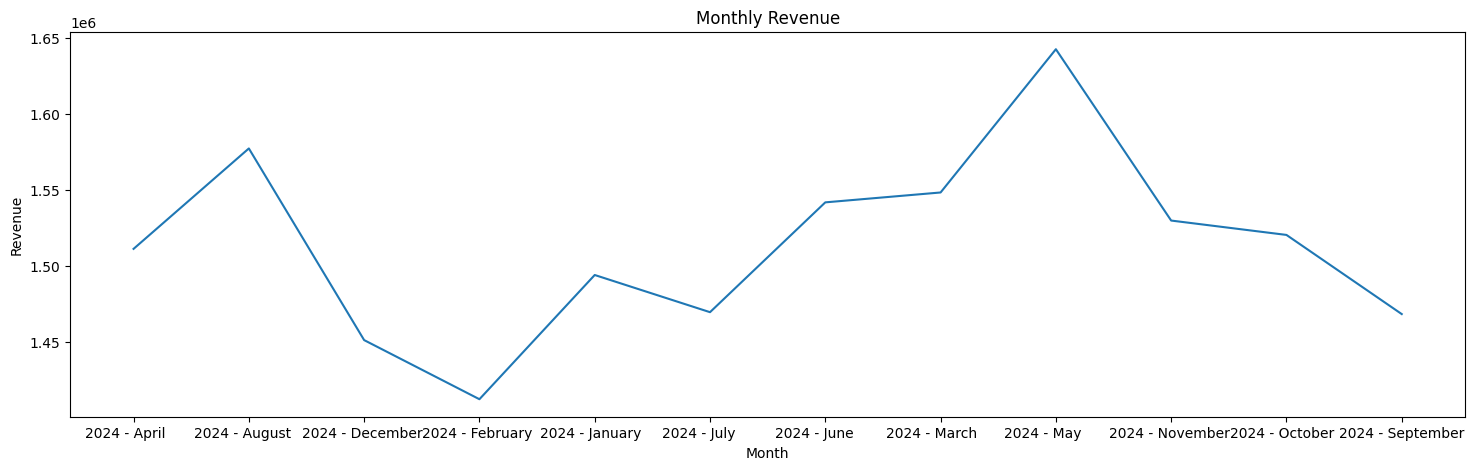

In [ ]:
try :
    query = """
        SELECT 
            TO_CHAR(orderdate,'YYYY - Month') AS MONTHS,
            SUM(totalamount) AS revenue
        FROM orders
        WHERE EXTRACT(YEAR FROM orderdate) = 2023
        GROUP BY TO_CHAR(orderdate,'YYYY - Month')
    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    months = [row[0] for row in rows]
    revenue = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)




import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))
plt.plot(months, revenue)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.show()

# Revenue by Category (Bar Chart)

## Objective

The purpose of this analysis is to identify which product categories generate the highest revenue.

## SQL Logic

The data is grouped using the **Category** column. The **SUM()** function calculates the total revenue generated by each category.

## Why Bar Chart?

A bar chart is the best choice for comparing values across different categories because it clearly shows which category has the highest and lowest revenue.

## Business Insight

This visualization helps businesses:

- Identify the highest-performing categories.
- Understand customer purchasing trends.
- Allocate inventory more effectively.
- Focus marketing efforts on profitable categories.

- Revenue by Category (Bar Chart)

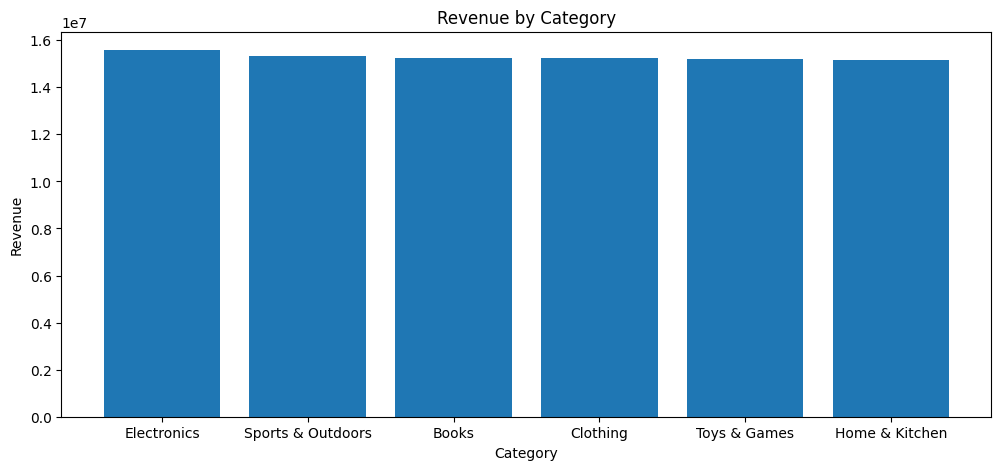

In [23]:

try :
    query = """
    SELECT
        category,
        SUM(totalamount) AS total_revenue
    FROM orders
    GROUP BY category
    ORDER BY total_revenue DESC;
    """

    cursor.execute(query)

    rows = cursor.fetchall()

    categories = [row[0] for row in rows]
    revenues = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(categories, revenues)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

# 📈 Monthly Revenue (Line Chart)

## Objective

Analyze how revenue changes month by month.

## SQL Logic

The database stores the transaction date in the **OrderDate** column. The month is extracted using SQL date functions such as **TO_CHAR()** or **EXTRACT()**, and the revenue is calculated using the **SUM()** function.

## Why Line Chart?

A line chart is the best visualization for time-series data because it clearly shows trends and changes over time.

## Business Insights

- Identify seasonal sales trends.
- Detect months with high or low revenue.
- Monitor business growth.
- Support future sales forecasting.

- Reusable Function for Bar Chart

In [ ]:


import matplotlib.pyplot as plt

def bar_chart(x, y,
              title="Bar Chart",
              xlabel="X-axis",
              ylabel="Y-axis",
              figsize=(12,5)):
    
    plt.figure(figsize=figsize)

    bars = plt.bar(x, y)

    # Value labels
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():,.0f}",
            ha="center",
            va="bottom"
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

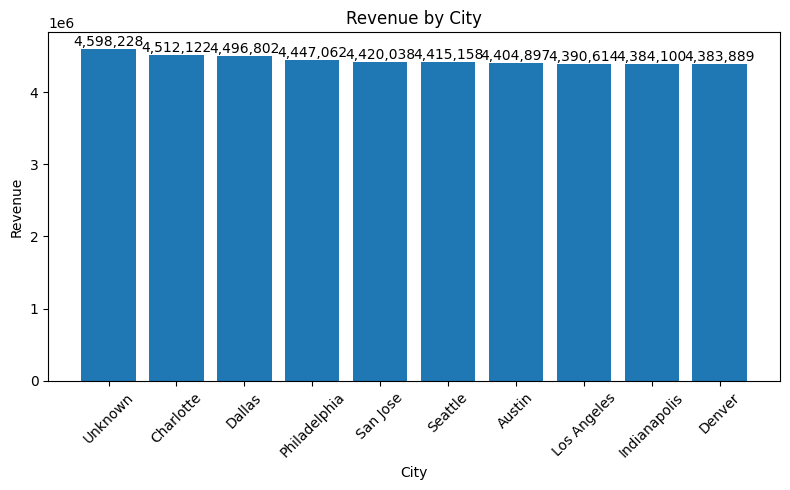

In [32]:
try :
    query = """
    SELECT
        city,
        SUM(totalamount) AS total_revenue
    FROM orders
    GROUP BY city
    ORDER BY total_revenue DESC
    LIMIT 10;
    """

    cursor.execute(query)

    rows = cursor.fetchall()

    cities = [row[0] for row in rows]
    revenues = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)


bar_chart(
    cities,
    revenues,
    title="Revenue by City",
    xlabel="City",
    ylabel="Revenue"
)



# 💳 Payment Analysis

Payment Analysis examines customer payment preferences and the revenue generated through different payment methods.

Understanding payment behavior helps businesses improve customer convenience and optimize payment services.

# 💰 Most Used Payment Method

## Objective

Identify the payment method used most frequently by customers.

## SQL Logic

The data is grouped by **Payment Method**, and the **COUNT()** function calculates the number of transactions for each payment method.

## Why Bar Chart?

A bar chart provides a clear comparison of transaction counts across different payment methods.

## Business Insights

- Understand customer payment preferences.
- Improve payment service availability.
- Promote popular payment options.

- Reuseable Code

In [34]:
import matplotlib.pyplot as plt

def pie_chart(labels,
              values,
              title="Pie Chart",
              figsize=(7,7)):

    plt.figure(figsize=figsize)

    plt.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(title)

    plt.axis("equal")

    plt.tight_layout()

    plt.show()

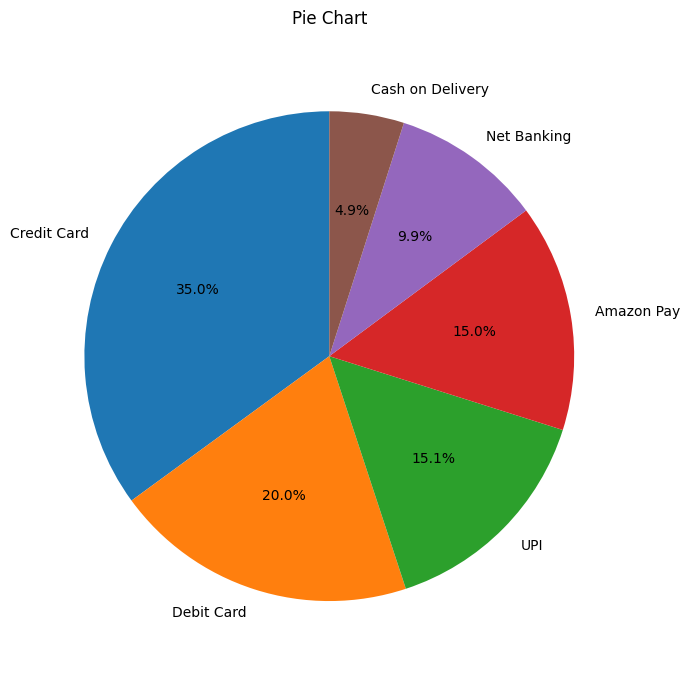

In [35]:
# Payment Method Distribution (Pie Chart)

# Step 1 : SQL Query
try :
    query = """
    SELECT
        paymentmethod,
        COUNT(totalamount) AS revenue
    FROM orders
    GROUP BY paymentmethod
    ORDER BY COUNT(totalamount) DESC ;
    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    labels = [row[0] for row in rows]
    values = [row[1] for row in rows]
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)


pie_chart(
    labels,
    values,
    title="Pie Chart",
    figsize=(7,7))


# 📊 Revenue Distribution (Histogram)

## Objective

Analyze how customer revenues are distributed across all orders.

## SQL Logic

The revenue column is selected directly without aggregation because each individual revenue is required to understand the distribution.

## Why Histogram?

A histogram groups continuous or numerical values into ranges (bins), making it easy to observe the frequency of different revenues.

## Business Insights

- Understand overall customer satisfaction.
- Detect whether revenues are mostly high or low.
- Identify patterns that may indicate quality or service issues.

- Resuseable code

In [36]:
def plot_histogram(data,
                   bins=10,
                   title="Histogram",
                   xlabel="Value",
                   ylabel="Frequency",
                   figsize=(8,5)):

    plt.figure(figsize=figsize)

    plt.hist(data, bins=bins)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.tight_layout()
    plt.show()

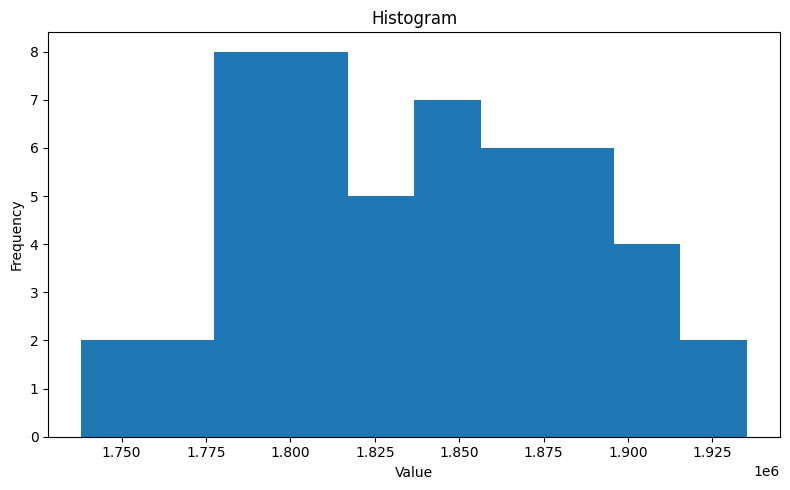

In [42]:
# Rating Distribution (Histogram)

try :
    query = """
    SELECT
        SUM(totalamount)
    FROM orders
    GROUP BY productname ;
    """

    cursor.execute(query)

    rows = cursor.fetchall()


# Step 2: SQL Result ko Python Lists me Convert karo
    data = [row[0] for row in rows]
    
except Exception as e:
    connection.rollback()
    print("❌ Query Failed")
    print(e)


plot_histogram(data,
                   bins=10,
                   title="Histogram",
                   xlabel="Value",
                   ylabel="Frequency",
                   figsize=(8,5))


# 📌 Conclusion

This analysis demonstrates how SQL queries can be combined with Python visualizations to generate meaningful business insights directly from a PostgreSQL database.

The workflow followed in this project is:

1. Connect Python with PostgreSQL.
2. Execute SQL queries.
3. Retrieve data using a cursor.
4. Process the query results in Python.
5. Create visualizations using Matplotlib.
6. Interpret the charts to support business decision-making.

These analyses reflect common tasks performed by Data Analysts to transform raw transactional data into actionable business insights.